## **Portfolio Management with linear algebra**

In [14]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

In [15]:
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM']
data = yf.download(tickers, start='2020-01-01', end='2024-01-01', auto_adjust=True)['Close']

[*********************100%***********************]  5 of 5 completed


In [16]:
# Log returns 
log_ret = np.log(data/ data.shift(1)).dropna()
log_ret.head()

Ticker,AAPL,AMZN,GOOGL,JPM,MSFT
Date,,,,,
2020-01-03,-0.009770,-0.012213,-0.005245,-0.013284,-0.012530
2020-01-06,0.007937,0.014776,0.026305,-0.000795,0.002581
2020-01-07,-0.004714,0.002089,-0.001933,-0.017147,-0.009159
2020-01-08,0.015958,-0.007839,0.007093,0.007771,0.015803
2020-01-09,0.021019,0.004788,0.010443,0.003644,0.012415


In [5]:
# Compute μ and Σ
mu = log_ret.mean() * 252
cov = log_ret.cov() * 252

Multiplying by 252 annualises from daily to yearly (trading days in a year)

In [8]:
# Monte Carlo Simulation
n_assets = len(tickers)
n_portfolios = 10000

results = np.zeros((3, n_portfolios))
all_weights = np.zeros((n_portfolios, n_assets))  

for i in range(n_portfolios):
    w = np.random.random(n_assets)
    w /= w.sum()
    
    all_weights[i] = w  # store weights for this portfolio
    
    ret = w @ mu
    std = np.sqrt(w @ cov.values @ w)
    sharpe = ret / std
    
    results[0, i] = ret
    results[1, i] = std
    results[2, i] = sharpe

In [9]:
def portfolio_variance(w, cov):
    return w.T @ cov.values @ w

def portfolio_return(w, mu):
    return w @ mu

constraints = [
    {'type': 'eq', 'fun': lambda w: w.sum() - 1},           # weights sum to 1
    {'type': 'eq', 'fun': lambda w: portfolio_return(w, mu) - target}  # hit target return
]

bounds = [(0, 1)] * n_assets

frontier_returns = np.linspace(mu.min(), mu.max(), 100)
frontier_vols = []
for target in frontier_returns:
    constraints[1]['fun'] = lambda w, t=target: portfolio_return(w, mu) - t
    result = minimize(portfolio_variance, x0=np.ones(n_assets)/n_assets,
                      args=(cov,), method='SLSQP',
                      bounds=bounds, constraints=constraints)
    frontier_vols.append(np.sqrt(result.fun))

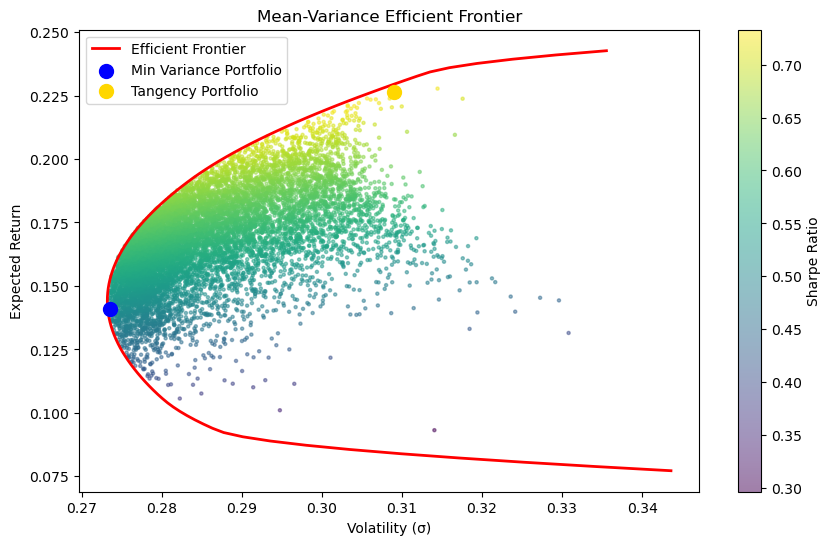

In [10]:
plt.figure(figsize=(10, 6))
portfolio_variance
# scatter cloud coloured by sharpe ratio
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.5, s=5)
plt.colorbar(label='Sharpe Ratio')

# true frontier curve
plt.plot(frontier_vols, frontier_returns, 'r-', linewidth=2, label='Efficient Frontier')

# minimum variance portfolio
min_vol_idx = results[1].argmin()
plt.scatter(results[1, min_vol_idx], results[0, min_vol_idx],
            color='blue', s=100, zorder=5, label='Min Variance Portfolio')

# tangency portfolio (max sharpe)
max_sharpe_idx = results[2].argmax()
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx],
            color='gold', s=100, zorder=5, label='Tangency Portfolio')

plt.xlabel('Volatility (σ)')
plt.ylabel('Expected Return')
plt.title('Mean-Variance Efficient Frontier')
plt.legend()
plt.show()

In [11]:
log_ret.corr()

Ticker,AAPL,AMZN,GOOGL,JPM,MSFT
Ticker,,,,,
AAPL,1.000000,0.626474,0.694517,0.460535,0.779636
AMZN,0.626474,1.000000,0.666772,0.272860,0.680748
GOOGL,0.694517,0.666772,1.000000,0.445099,0.773929
JPM,0.460535,0.272860,0.445099,1.000000,0.452751
MSFT,0.779636,0.680748,0.773929,0.452751,1.000000


In [12]:
# Minimum variance portfolio
min_vol_idx = results[1].argmin()
min_var_weights = all_weights[min_vol_idx]

# Tangency portfolio (max sharpe)
max_sharpe_idx = results[2].argmax()
tangency_weights = all_weights[max_sharpe_idx]

# Display
min_var_portfolio = pd.Series(min_var_weights, index=tickers)
tangency_portfolio = pd.Series(tangency_weights, index=tickers)

print("Minimum Variance Portfolio:")
print(min_var_portfolio.round(4))

print("\nTangency Portfolio:")
print(tangency_portfolio.round(4))

Minimum Variance Portfolio:
AAPL     0.1299
MSFT     0.2226
GOOGL    0.1142
AMZN     0.3866
JPM      0.1468
dtype: float64

Tangency Portfolio:
AAPL     0.6331
MSFT     0.0305
GOOGL    0.0070
AMZN     0.0367
JPM      0.2926
dtype: float64


In [13]:
print("\nPortfolio Statistics:")
print(f"MVP - Return: {results[0, min_vol_idx]:.2%}, Vol: {results[1, min_vol_idx]:.2%}, Sharpe: {results[2, min_vol_idx]:.2f}")
print(f"Tangency - Return: {results[0, max_sharpe_idx]:.2%}, Vol: {results[1, max_sharpe_idx]:.2%}, Sharpe: {results[2, max_sharpe_idx]:.2f}")


Portfolio Statistics:
MVP - Return: 14.07%, Vol: 27.35%, Sharpe: 0.51
Tangency - Return: 22.64%, Vol: 30.90%, Sharpe: 0.73
